<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-12 </h1> </html>

The tutorial will cover the following:

* Preparing a simple dataset for time series forecasting
* How to use a network built via SimpleRNN for time series forecasting
* Adding a custom attention layer to the SimpleRNN network

<html> <h2 style="font-style:italic; color:blue;"> Attention Networks </21> </html>

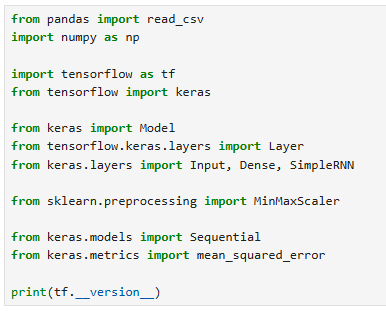

In [ ]:
from pandas import read_csv
import numpy as np

import tensorflow as tf
from tensorflow import keras

from keras import Model
from tensorflow.keras.layers import Layer
from keras.layers import Input, Dense, SimpleRNN

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.metrics import mean_squared_error

print(tf.__version__)

2.20.0


### The Dataset

We will create a fibonacci sequence dataset for our purpose. In Fibonacci sequence, one number is constructed from the previous two numbers. The first 10 numbers of the sequence are shown below:

0, 1, 1, 2, 3, 5, 8, 13, 21, 34, …


When given the previous ‘t’ numbers, can you get a machine to accurately reconstruct the next number? This would mean discarding all the previous inputs except the last two and performing the correct operation on the last two numbers.

For this tutorial, you’ll construct the training examples from t time steps and use the value at t+1 as the target. For example, if t=3, then the training examples and the corresponding target values would look as follows:


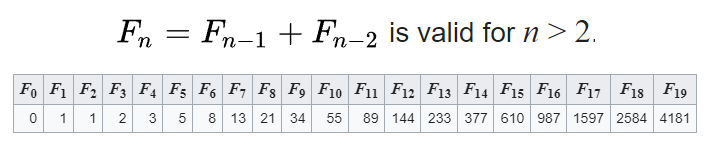

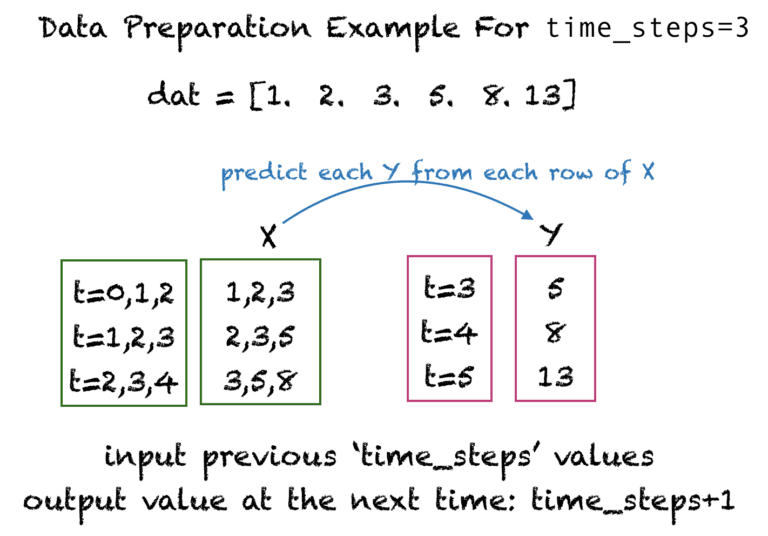

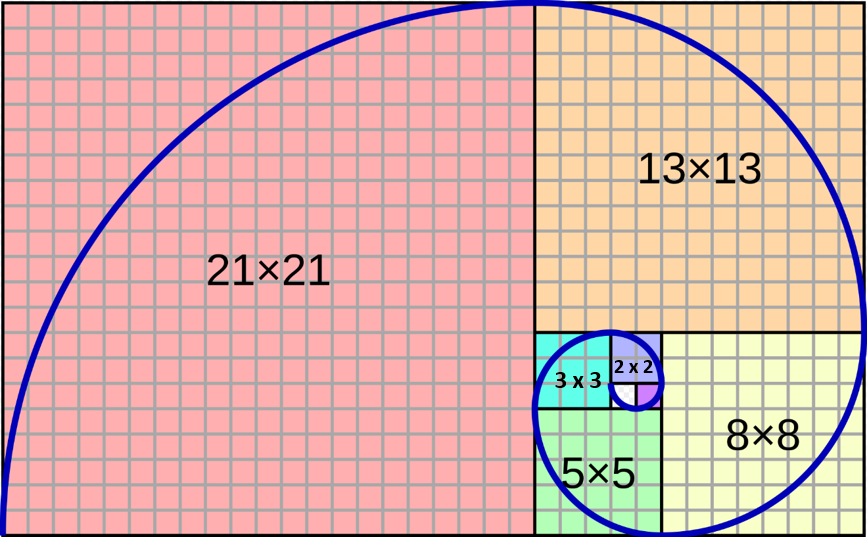

The Fibonacci spiral: an approximation of the **golden spiral** created by drawing circular arcs connecting the opposite corners of squares in the Fibonacci tiling

### Data preprocessing

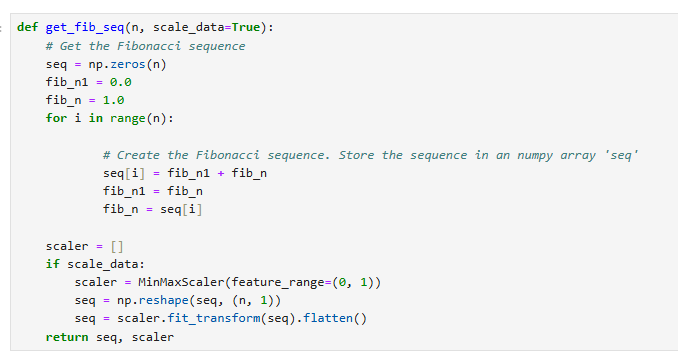

In [ ]:

def get_fib_seq(n, scale_data=True):
  # Get the Fibonacci sequence
  seq = np.zeros(n)
  fib_n1 = 0.0
  fib_n = 1.0

  for i in range(n):
    # Create the Fibonacci sequence. Store the sequence in an numpy array 'seq'
    seq[i] = fib_n1 + fib_n
    fib_n1 = fib_n
    fib_n = seq[i]

  scaler = []

  if scale_data:
    scaler = MinMaxScaler (feature_range=(0, 1))
    seq = np.reshape(seq, (n, 1))
    seq = scaler.fit_transform(seq). flatten()
  return seq, scaler

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

In [ ]:
# Check if the function works correctly:
# Copy the previous cell, change the function name and add fib_n

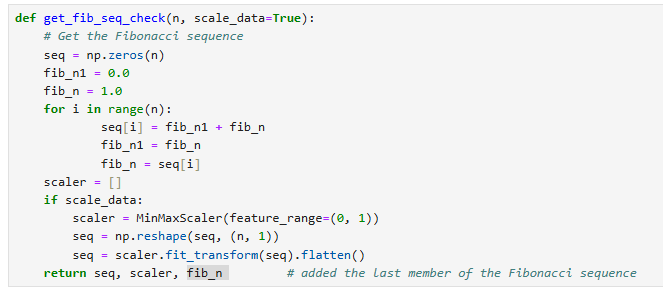

In [ ]:

def get_fib_seq_check(n, scale_data=True):
  seq= np.zeros(n)
  fib_n1 = 0.0
  fib_n = 1.0

  for i in range(n):
    seq[i] = fib_n1 + fib_n
    fib_n1 = fib_n
    fib_n = seq[i]
  scaler = []

  if scale_data:
    scaler = MinMaxScaler (feature_range=(0, 1))
    seq = np.reshape(seq, (n, 1))
    seq = scaler.fit_transform(seq). flatten()
  return seq, scaler, fib_n

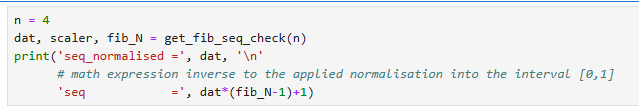

In [ ]:

n = 4
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
  # math expression inverse to the applied normalisation into the interval [0,1]
  'seq =', dat * (fib_N-1)+1)

seq_normalised =  [0.   0.25 0.5  1.  ] 
seq = [1. 2. 3. 5.]


In [ ]:
# Your code for the same checking with n=6

n = 6
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
  # math expression inverse to the applied normalisation into the interval [0,1]
  'seq =', dat * (fib_N-1)+1)


seq_normalised =  [0.         0.08333333 0.16666667 0.33333333 0.58333333 1.        ] 
seq = [ 1.  2.  3.  5.  8. 13.]


In [ ]:
# Your code for the same checking with n=8

n = 8
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
  # math expression inverse to the applied normalisation into the interval [0,1]
  'seq =', dat * (fib_N-1)+1)

seq_normalised =  [0.         0.03030303 0.06060606 0.12121212 0.21212121 0.36363636
 0.60606061 1.        ] 
seq = [ 1.  2.  3.  5.  8. 13. 21. 34.]


In [ ]:
# Your code for the same checking with n=10

n = 10
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised = ', dat, '\n'
  # math expression inverse to the applied normalisation into the interval [0,1]
  'seq =', dat * (fib_N-1)+1)

seq_normalised =  [0.         0.01136364 0.02272727 0.04545455 0.07954545 0.13636364
 0.22727273 0.375      0.61363636 1.        ] 
seq = [ 1.  2.  3.  5.  8. 13. 21. 34. 55. 89.]


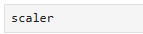

In [ ]:
scaler

MinMaxScaler()

In [ ]:
MinMaxScaler()

MinMaxScaler()

### The following function transforms the fibonacci sequence into training and test dataset.

X and Y looks like the following. From X and Y, we create training and test dataset.


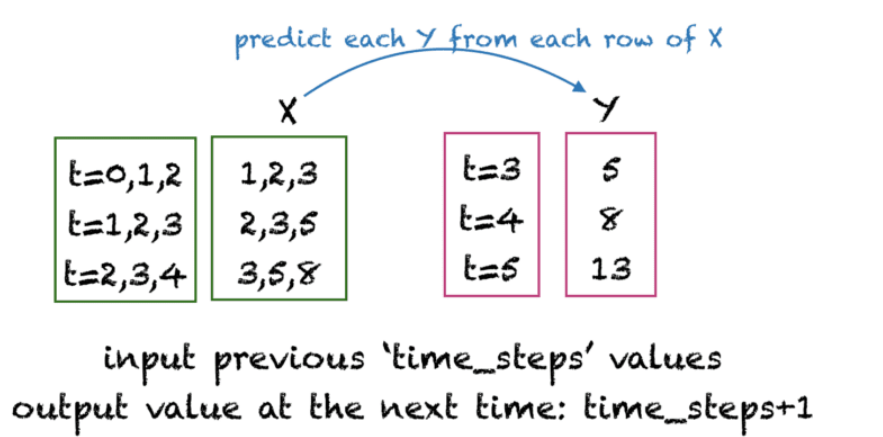

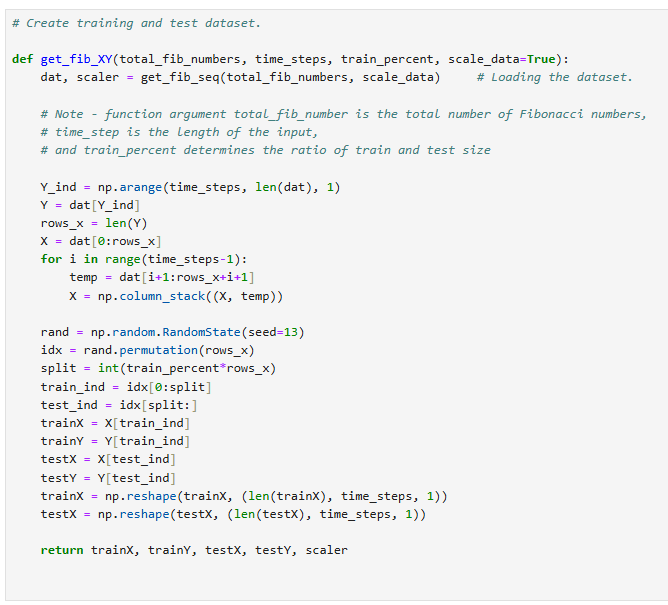

In [ ]:
def get_fib_XY(total_fib_numbers, time_steps, train_percent, scale_data=True):
  dat, scaler = get_fib_seq(total_fib_numbers, scale_data)

  Y_ind = np.arange(time_steps, len(dat), 1)
  Y = dat [Y_ind]
  rows_x = len(Y)
  X = dat [0:rows_x]
  for i in range(time_steps-1):
   temp = dat [i+1:rows_x+i+1]
   X = np.column_stack((X, temp))

  rand = np.random.RandomState(seed=13)
  idx= rand.permutation (rows_x)
  split = int (train_percent*rows_x)
  train_ind = idx[0:split]
  test_ind = idx[split:]
  trainX = X[train_ind]
  trainY = Y[train_ind]
  testX = X[test_ind]
  testy = Y[test_ind]
  trainX = np.reshape(trainX, (len(trainX), time_steps, 1))
  testX = np.reshape(testX, (len(testX), time_steps, 1))

  return trainX, trainY, testX, testy, scaler

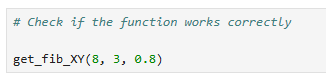

In [ ]:
get_fib_XY(8, 3, 0.8)

(array([[[0.03030303],
         [0.06060606],
         [0.12121212]],
 
        [[0.12121212],
         [0.21212121],
         [0.36363636]],
 
        [[0.21212121],
         [0.36363636],
         [0.60606061]],
 
        [[0.        ],
         [0.03030303],
         [0.06060606]]]),
 array([0.21212121, 0.60606061, 1.        , 0.12121212]),
 array([[[0.06060606],
         [0.12121212],
         [0.21212121]]]),
 array([0.36363636]),
 MinMaxScaler())

In [ ]:
#np.column_stack?

In [ ]:
#np.random.RandomState.permutation?

### In the following code, we test the performance with the help of a simple RNN.


#### Set up parameters

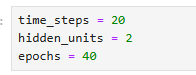

In [ ]:
time_steps = 20
hidden_units = 2
epochs = 40

#### Create a traditional RNN network

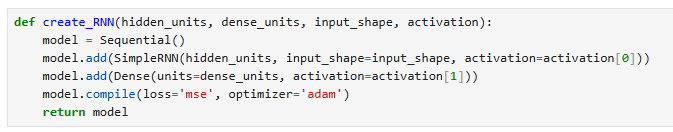

In [ ]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
  model = Sequential()
  model.add(SimpleRNN (hidden_units, input_shape=input_shape, activation=activation[0]))
  model.add(Dense(units=dense_units, activation=activation [1]))
  model.compile(loss='mse', optimizer='adam')
  return model

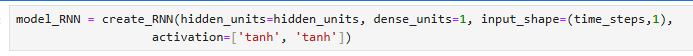

In [ ]:
model_RNN = create_RNN(hidden_units=hidden_units, dense_units=1, input_shape=(time_steps,1),
                       activation=['tanh', 'tanh'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


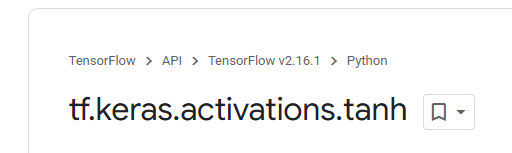

##### tf.keras.activations.tanh

https://www.tensorflow.org/api_docs/python/tf/keras/activations/tanh

In [ ]:
# Your code to print the model summary

model_RNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

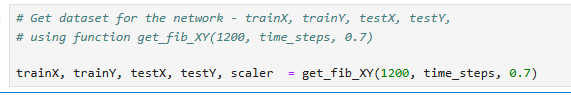

In [ ]:
trainX, trainY, testX, testY, scaler = get_fib_XY(1200, time_steps, 0.7)

#### Train the network

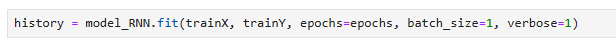

In [ ]:
history = model_RNN.fit(trainX, trainY, epochs=epochs, batch_size=1, verbose=1)

Epoch 1/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0025
Epoch 2/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0023    
Epoch 3/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0020    
Epoch 4/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0018
Epoch 5/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0016
Epoch 6/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014    
Epoch 7/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0012    
Epoch 8/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0010    
Epoch 9/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 9.0102e-04
Epoch 10/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 7.5725e-04
Epoch 11/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 6.4359e-04
Epoch 12/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.3720e-04
Epoch 13/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 4.3767e-04
Epoch 14/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3.4860e-04
Epoch 15/40
8

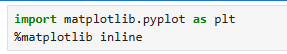

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

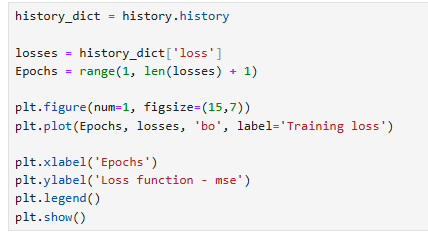

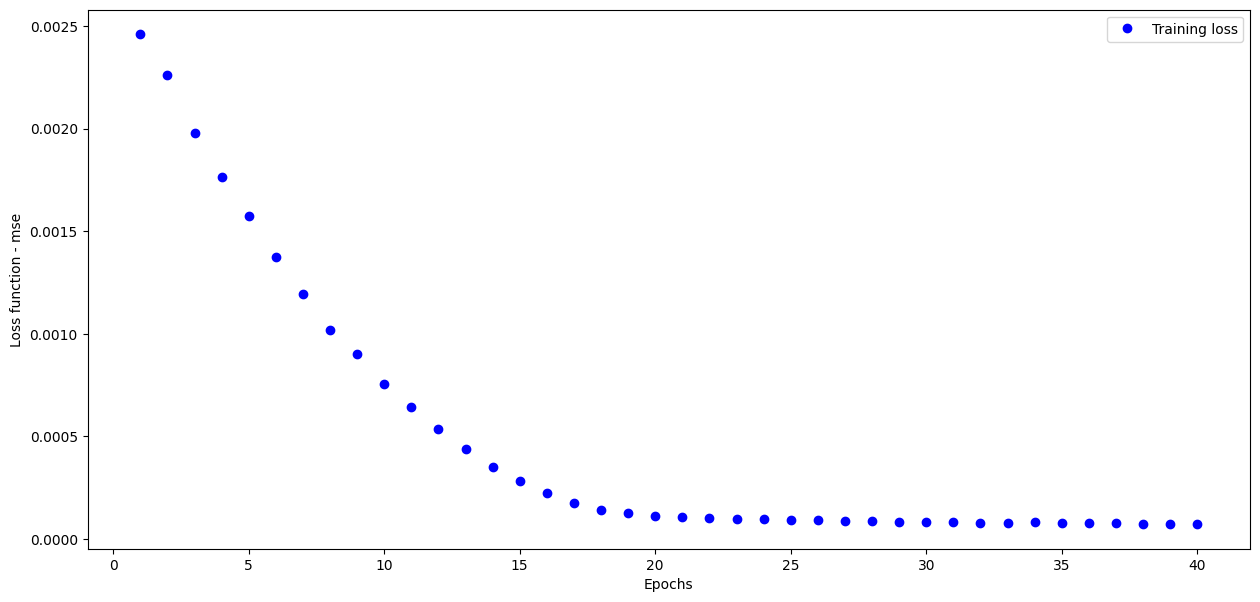

In [ ]:
history_dict = history.history

losses = history_dict['loss']
Epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(Epochs, losses, 'bo', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

#### Evalute model

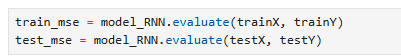

In [ ]:
train_mse = model_RNN.evaluate(trainX, trainY)
test_mse = model_RNN.evaluate(testX, testY)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.9742e-05
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.1158e-05


#### Print train and test error metrics

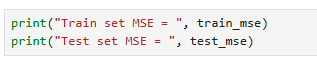

In [ ]:
print("Train set MSE = ", train_mse)
print("Test set MSE = ", test_mse)

Train set MSE =  5.974197119940072e-05
Test set MSE =  2.115760617016349e-05


In [ ]:
print("Train set MSE = ", train_mse)
print("Test set MSE = ", test_mse)

Train set MSE =  5.974197119940072e-05
Test set MSE =  2.115760617016349e-05


### The following code creates an attention layer. You need to understand each line to know how an attention layer can be created.


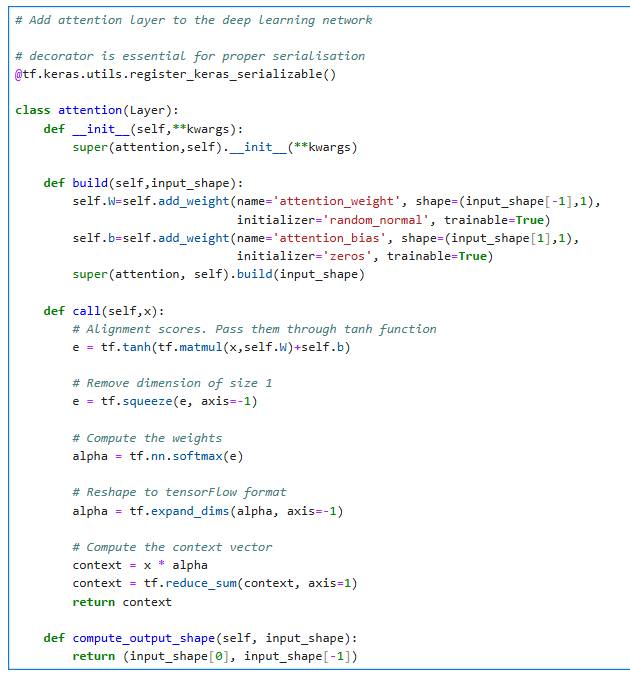

In [ ]:
@tf.keras.utils.register_keras_serializable()

class attention (Layer):
  def __init__(self, **kwargs):
    super(attention, self).__init__(**kwargs)

  def build(self, input_shape):
    self.W=self.add_weight(name='attention_weight', shape=(input_shape[-1],1),
                           initializer='random_normal', trainable=True)
    self.b=self.add_weight(name='attention_bias', shape=(input_shape[1],1),
                           initializer='zeros', trainable=True)
    super(attention, self).build(input_shape)

  def call(self,x):
    e = tf.tanh(tf.matmul(x,self.W)+self.b)
    e = tf.squeeze(e, axis=-1)
    alpha = tf.nn.softmax(e)
    alpha = tf.expand_dims(alpha, axis=-1)

    context = x * alpha
    context = tf.reduce_sum(context, axis=1)
    return context
    def compute_output_shape(self, input_shape):
      return (input_shape[0], input_shape[-1])

### The following code develops an RNN with an attention layer to predict the Fibonacci sequence.



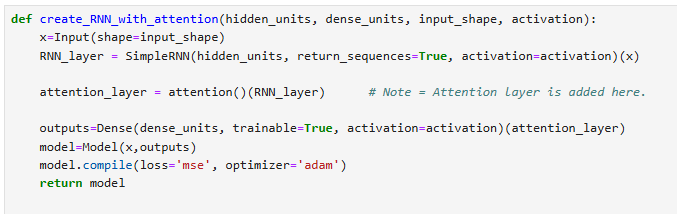

In [ ]:
def create_RNN_with_attention (hidden_units, dense_units, input_shape, activation):
  x=Input(shape=input_shape)
  RNN_layer = SimpleRNN (hidden_units, return_sequences=True, activation=activation)(x)

  attention_layer = attention()(RNN_layer)

  outputs=Dense(dense_units, trainable=True, activation=activation)(attention_layer)
  model=Model(x, outputs)
  model.compile(loss='mse', optimizer='adam')
  return model

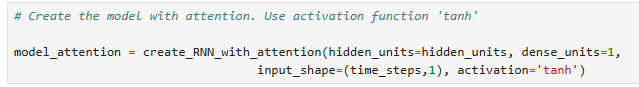

In [ ]:
model_attention = create_RNN_with_attention (hidden_units=hidden_units, dense_units=1,
                                  input_shape=(time_steps,1), activation= 'tanh')

In [ ]:
# Your code to print the model summary

model_attention.summary()



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20, 2)          │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (attention)           │ (None, 2)              │            22 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Your code to fit the model
# save the results of the training to 'history_2' variable list
# use batch_size=1


history_2 = model_attention.fit(trainX, trainY, epochs=epochs, batch_size=1, verbose=1)

Epoch 1/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0015
Epoch 2/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015
Epoch 3/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015
Epoch 4/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0015
Epoch 5/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015    
Epoch 6/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0015    
Epoch 7/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015
Epoch 8/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0015    
Epoch 9/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0015
Epoch 10/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0015
Epoch 11/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014
Epoch 12/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0014
Epoch 13/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0014
Epoch 14/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0014
Epoch 15/40
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.


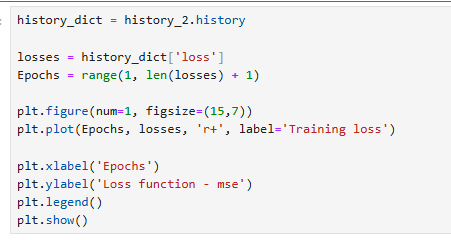

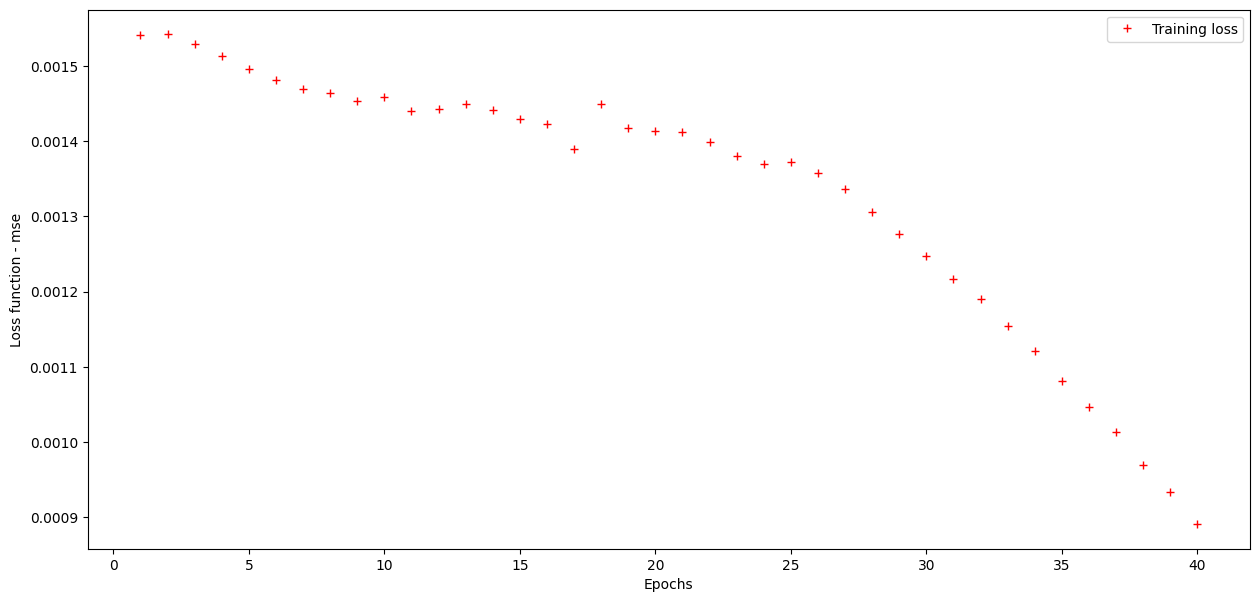

In [ ]:
history_dict = history_2.history

losses = history_dict['loss']
Epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(Epochs, losses, 'r+', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

In [ ]:
# Your code to Evaluate attention model on training set
# Your code to evaluate the attention model on the test set

train_mse_attn = model_attention.evaluate(trainX, trainY)
test_mse_attn = model_attention.evaluate(testX, testY)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.3486e-04
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 7.3704e-04


In [ ]:
# Your code to print train error metric
# Your code to print test error metric

print("Train set MSE (with attention) = ", train_mse_attn)
print("Test set MSE (with attention) = ", test_mse_attn)

Train set MSE (with attention) =  0.0008348636329174042
Test set MSE (with attention) =  0.0007370435050688684


In [ ]:
# Draw both loss functions' graphs together

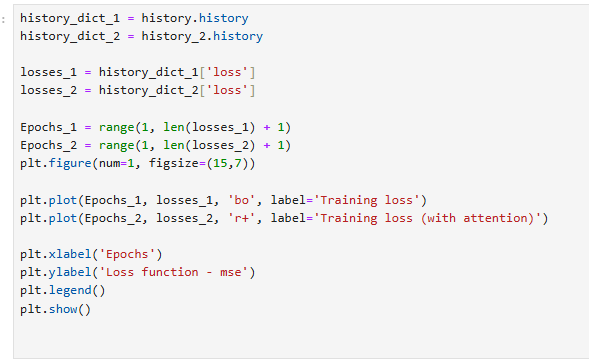

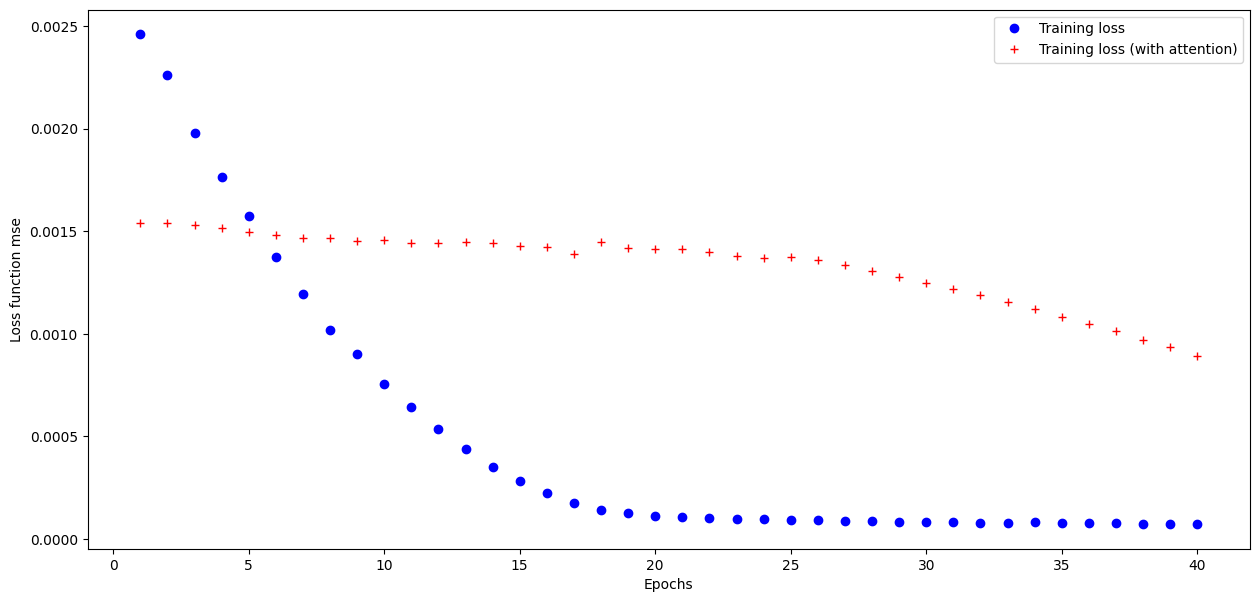

In [ ]:

history_dict_1 = history.history
history_dict_2 = history_2.history

losses_1 = history_dict_1['loss']
losses_2 = history_dict_2['loss']

Epochs_1 = range (1, len (losses_1) + 1)
Epochs_2 = range (1, len(losses_2) + 1)
plt.figure(num=1, figsize=(15,7))

plt.plot(Epochs_1, losses_1, 'bo', label='Training loss')
plt.plot(Epochs_2, losses_2, 'r+', label='Training loss (with attention)')

plt.xlabel('Epochs')
plt.ylabel('Loss function mse')
plt.legend()
plt.show()

### Plot the train and test MSE performance for the 'Simple RNN' and 'RNN with an attention layer'.


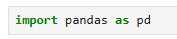

In [ ]:
import pandas as pd

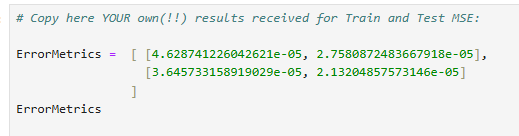

In [ ]:
train_mse_rnn_new = 5.974197119940072e-05
test_mse_rnn_new = 2.115760617016349e-05

train_mse_attn = 0.0008348636329174042
test_mse_attn = 0.0007370435050688684

In [ ]:
ErrorMetrics = [
    [train_mse_rnn_new, test_mse_rnn_new],
    [train_mse_attn, test_mse_attn]
]
ErrorMetrics

[[5.974197119940072e-05, 2.115760617016349e-05],
 [0.0008348636329174042, 0.0007370435050688684]]

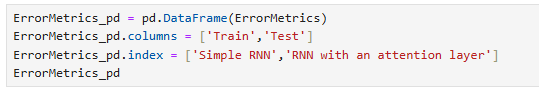

In [ ]:
ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns = ['Train', 'Test']
ErrorMetrics_pd.index = ['Simple RNN', 'RNN with an attention layer']
ErrorMetrics_pd

,Train,Test
Simple RNN,0.000060,0.000021
RNN with an attention layer,0.000835,0.000737


In [ ]:
## MSE performance histogram

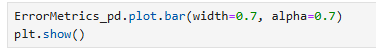

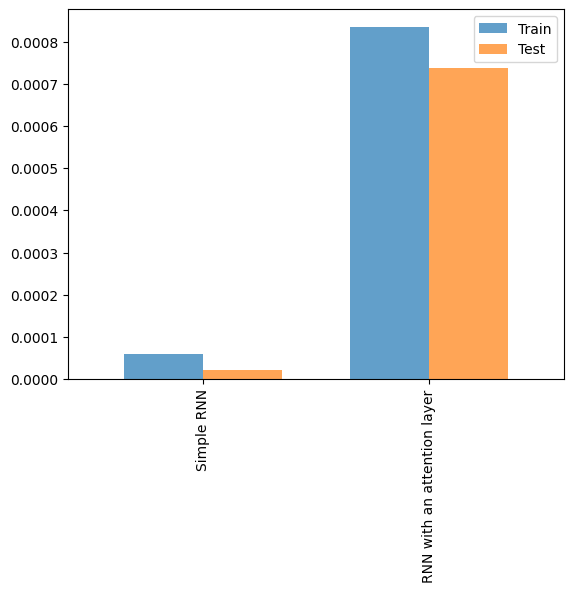

In [ ]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.show()

# Lab Logbook Requirement:

<html> <h3 style="; color:blue;">

1) Modify the training parameter of the RNN with an attention layer model using the following formulas:

Modify the number of epochs:
Z + 50
, where your SID is: XXXXXXZ

Use EarlyStopping() and ModelCheckpoint() function to save the best modetl in the file 'best_attention_model.keras'
Modify the patience parameter:
Z + 10
, where your SID is: XXXXXXZ

2) Modify time_steps = 20 and hidden_units = 4
3) Leave other parameters the same as in the practical session
4) Calculate and demonstrate the received loss for train and test datasets
5) Plot the Loss function (MSE) graph during the training process for the 3 models together
6) Please only add to your Lab Logbook print-screens of:
- calculation of your parameters
- your code of using EarlyStopping() and ModelCheckpoint() functions
- your code and training result using model.fit()
- received loss for train and test datasets
- Loss (MSE) graph for the 3 models together during the training process
- performance histogram for train and test loss (MSE) of the 3 models together


</h3> </html>


<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.
</h3> </html>

### Test the above model with different parameters, layer size, train and test ratio, and time steps.



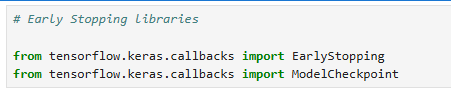

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


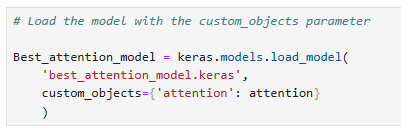

In [ ]:
Best_attention_model = keras.models.load_model(
'/content/drive/MyDrive/best_attention_model.keras',
custom_objects={'attention': attention}
)

In [ ]:
# Your code of parameter modification

time_steps = 20 #@param {type:"integer"}

hidden_units = 4 #@param {type:"integer"}

epochs = 54 #@param {type:"integer"}

patience = 14 #@param {type:"integer"}

In [ ]:
# Continue your code according to the Lab Logbook Requirements ...


In [ ]:
# Callbacks for EarlyStopping and ModelCheckpoint
es = EarlyStopping(monitor='loss', mode='min', verbose=1, patience=patience, restore_best_weights=True)
mc = ModelCheckpoint('best_attention_model.keras', monitor='loss', mode='min', verbose=1, save_best_only=True)


### Current parameters for the models:

In [ ]:
print(f"Time Steps: {time_steps}")
print(f"Hidden Units: {hidden_units}")
print(f"Epochs: {epochs}")
print(f"Patience for EarlyStopping: {patience}")

Time Steps: 20
Hidden Units: 4
Epochs: 54
Patience for EarlyStopping: 14


### Retraining the Simple RNN with updated `hidden_units = 4`

In [ ]:
# Save the history and metrics of the original SimpleRNN (hidden_units=2)
history_rnn_old_params = history
# train_mse and test_mse variables already hold values for hidden_units=2
train_mse_rnn_old = train_mse
test_mse_rnn_old = test_mse

# Recreate SimpleRNN model with new hidden units (which is now 4)
model_RNN_new_params = create_RNN(hidden_units=hidden_units, dense_units=1, input_shape=(time_steps,1),
                       activation=['tanh', 'tanh'])
model_RNN_new_params.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

#### Train the re-created Simple RNN

In [ ]:
history_rnn_new_params = model_RNN_new_params.fit(trainX, trainY, epochs=epochs, batch_size=1, verbose=1,callbacks=[es,mc])

Epoch 1/54
818/826 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0180
Epoch 1: loss improved from None to 0.00520, saving model to best_attention_model.keras

Epoch 1: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0052
Epoch 2/54
821/826 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028
Epoch 2: loss improved from 0.00520 to 0.00457, saving model to best_attention_model.keras

Epoch 2: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0046
Epoch 3/54
826/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 3: loss improved from 0.00457 to 0.00387, saving model to best_attention_model.keras

Epoch 3: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0039
Epoch 4/54
824/826 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5294e-04
Epoch 4: loss improved from 0.00387 to 0.00325, saving model to best_attention_model.keras

Epoch 4: fin

#### Evaluate re-created Simple RNN model

In [ ]:
train_mse_rnn_new = model_RNN_new_params.evaluate(trainX, trainY)
test_mse_rnn_new = model_RNN_new_params.evaluate(testX, testY)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.5425e-05
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.6109e-05


### Print all train and test error metrics

In [ ]:
print("Simple RNN (original, hidden_units=2) Train set MSE = ", train_mse_rnn_old)
print("Simple RNN (original, hidden_units=2) Test set MSE = ", test_mse_rnn_old)
print("\nSimple RNN (new, hidden_units=4) Train set MSE = ", train_mse_rnn_new)
print("Simple RNN (new, hidden_units=4) Test set MSE = ", test_mse_rnn_new)
print("\nRNN with Attention Train set MSE = ", train_mse_attn)
print("RNN with Attention Test set MSE = ", test_mse_attn)

Simple RNN (original, hidden_units=2) Train set MSE =  5.974197119940072e-05
Simple RNN (original, hidden_units=2) Test set MSE =  2.115760617016349e-05

Simple RNN (new, hidden_units=4) Train set MSE =  3.542465128703043e-05
Simple RNN (new, hidden_units=4) Test set MSE =  2.6109435566468164e-05

RNN with Attention Train set MSE =  0.0008348636329174042
RNN with Attention Test set MSE =  0.0007370435050688684


In [ ]:
ErrorMetrics = [
    [train_mse_rnn_old, test_mse_rnn_old],
    [train_mse_rnn_new, test_mse_rnn_new],
    [train_mse_attn, test_mse_attn]
]
ErrorMetrics

[[5.974197119940072e-05, 2.115760617016349e-05],
 [3.542465128703043e-05, 2.6109435566468164e-05],
 [0.0008348636329174042, 0.0007370435050688684]]

In [ ]:
ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns = ['Train', 'Test']
ErrorMetrics_pd.index = ['Simple RNN (orig)', 'Simple RNN (new)', 'RNN with an attention layer']
ErrorMetrics_pd

,Train,Test
Simple RNN (orig),0.000060,0.000021
Simple RNN (new),0.000035,0.000026
RNN with an attention layer,0.000835,0.000737


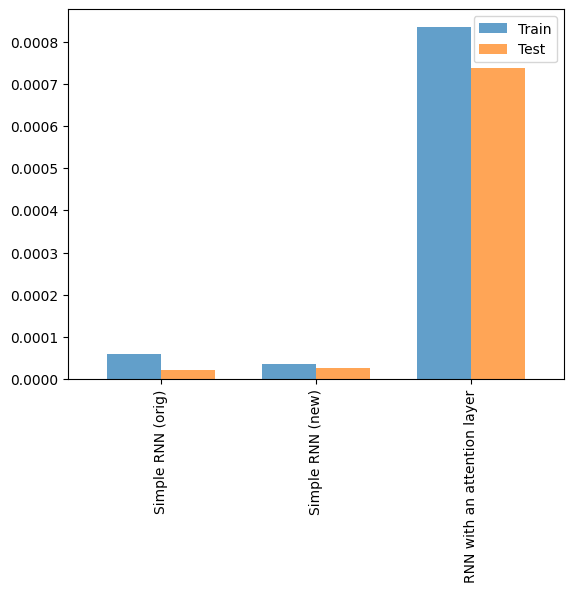

In [ ]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.show()

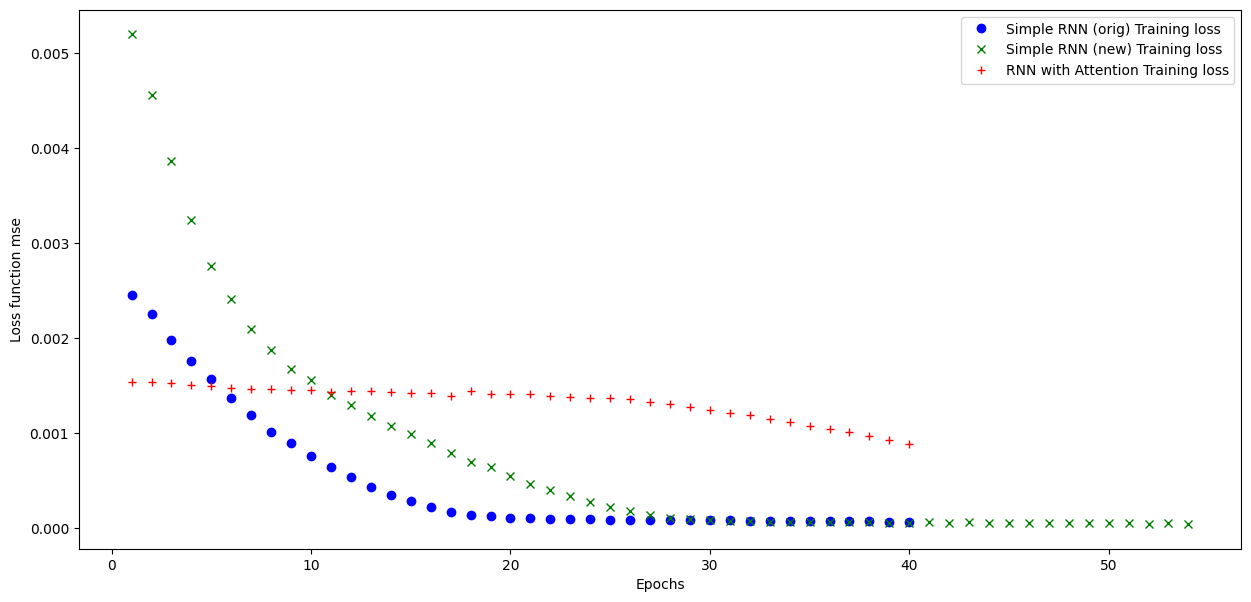

In [ ]:
history_dict_rnn_old = history_rnn_old_params.history
history_dict_rnn_new = history_rnn_new_params.history
history_dict_attention = history_2.history

losses_rnn_old = history_dict_rnn_old['loss']
losses_rnn_new = history_dict_rnn_new['loss']
losses_attention = history_dict_attention['loss']

Epochs_old = range(1, len(losses_rnn_old) + 1)
Epochs_new = range(1, len(losses_rnn_new) + 1)
Epochs_attention = range(1, len(losses_attention) + 1)

plt.figure(num=1, figsize=(15,7))

plt.plot(Epochs_old, losses_rnn_old, 'bo', label='Simple RNN (orig) Training loss')
plt.plot(Epochs_new, losses_rnn_new, 'gx', label='Simple RNN (new) Training loss')
plt.plot(Epochs_attention, losses_attention, 'r+', label='RNN with Attention Training loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function mse')
plt.legend()
plt.show()